# 🏥 Heart Failure Risk Prediction  

---

## 🧐 Context  

**Heart failure** is a severe chronic condition that impairs the heart’s ability to pump blood effectively. It can lead to life-threatening complications if not detected early.  

With the advancement of **medical data analysis** and **artificial intelligence**, we can now develop predictive models to assess heart failure risk and assist doctors in making more informed decisions.  

---

## 🎯 Project Objectives  

📌 **Our goal?** Develop a **Machine Learning model** capable of **predicting the risk of death** due to heart failure based on clinical data.  

📌 **Why?**  
🔹 Improve **patient care** and early risk detection.  
🔹 Identify the **most influential medical factors**.  
🔹 Provide a **clear explanation** of model predictions using **SHAP**.  
🔹 Design an **intuitive interface** for seamless clinical use.  



--
--

---

## 📊 Dataset Source  

📂 **Dataset Name**: *Heart Failure Clinical Records*  
📍 **Source**: UCI Machine Learning Repository  
🔗 **Link**: [UCI Heart Failure Dataset](https://archive.ics.uci.edu/dataset/519/heart%2Bfailure%2Bclinical%2Brecords)  

> 💡 This dataset contains **clinical data** on patients with heart failure, including biological measurements, medical history, and follow-up information. It serves as the foundation for training and testing our predictive models.  

---





## 🤖 Machine Learning Methodology  

📌 **1. Data Collection & Preprocessing**  
✔️ Load the dataset and explore its structure.  
✔️ Handle missing values and detect outliers.  
✔️ Optimize memory usage to improve performance.  
✔️ Perform feature selection and engineering if necessary.  

📌 **2. Handling Class Imbalance**  
✔️ Analyze the dataset distribution (68% survived, 32% deceased).  
✔️ Apply class balancing techniques such as **SMOTE, undersampling, or class-weighting**.  

📌 **3. Model Selection & Training**  
✔️ Choose at least three models for evaluation:  
   - Random Forest  
   - XGBoost  
   - LightGBM  
   - Logistic Regression  
✔️ Split the dataset into **training** and **test** sets.  
✔️ Train models using **cross-validation** for robustness.  

📌 **4. Model Evaluation**  
✔️ Assess performance using the following metrics:  
   - **ROC-AUC Score**  
   - **Accuracy**  
   - **Precision, Recall & F1-score**  
✔️ Compare model results and select the best-performing one.  

📌 **5. Model Explainability with SHAP**  
✔️ Implement **SHAP (SHapley Additive exPlanations)** to interpret model predictions.  
✔️ Generate **SHAP summary plots** to visualize feature importance.  

📌 **6. Deployment & User Interface**  
✔️ Develop an interactive **Flask** web application for real-time predictions.  
✔️ Allow physicians to input patient data and visualize results.  

---


****REQUIREMENTS INSTALLATION****

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, chi2, f_classif
from sklearn.feature_selection import VarianceThreshold

# 1. Read Dataset

In [2]:
# Chargement du fichier
data = pd.read_csv("heart_failure_clinical_records_dataset.csv")

In [ ]:
#Taille des données
data.shape

total = data.shape[0]
print("total of pacients %s"%(total))
print(f"The dataset has {data.shape[1]} features from {data.shape[0]} patients")

total of pacients 299
The dataset has 13 features from 299 patients


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  DEATH_EVENT               299 non-null    int64  
dtypes: float64(3), int64(10)
memory usage: 30.5 KB


In [ ]:
data.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


---

## 📌 **Description des Colonnes du Dataset**

| Nom de la colonne              | Description claire                                       | Type            | Unité                | Remarque                             |
|--------------------------------|----------------------------------------------------------|-----------------|----------------------|--------------------------------------|
| **anaemia**                    | Diminution des globules rouges ou de l'hémoglobine       | Booléen         | 0 (Non), 1 (Oui)    | Indicateur médical (anémie)          |
| **creatinine_phosphokinase**   | Niveau de l'enzyme CPK dans le sang                      | Quantitatif     | mcg/L                | Marqueur de lésion musculaire        |
| **diabetes**                   | Présence ou absence du diabète                           | Booléen         | 0 (Non), 1 (Oui)     | Facteur de risque cardiovasculaire   |
| **ejection_fraction**          | Fraction de sang éjectée du ventricule gauche            | Quantitatif     | Pourcentage (%)      | Indicateur clé de la fonction cardiaque |
| **high_blood_pressure**        | Hypertension artérielle                                  | Booléen         | 0=Non, 1=Oui         | Facteur de risque cardiovasculaire   |
| **platelets**                  | Nombre de plaquettes sanguines                           | Quantitatif     | kiloplaquettes/mL    | Important pour la coagulation        |
| **serum_creatinine**           | Concentration de créatinine sérique                      | Quantitatif     | mg/dL                | Indicateur de la fonction rénale     |
| **serum_sodium**               | Concentration de sodium dans le sang                     | Quantitatif     | mEq/L                | Régulateur nerveux et musculaire     |
| **sex**                        | Genre du patient                                         | Booléen         | 0=Femme, 1=Homme     | Caractéristique démographique        |
| **smoking**                    | Antécédent ou tabagisme actif                            | Booléen         | 0=Non, 1=Oui         | Facteur de risque cardiovasculaire   |
| **time**                       | Durée de suivi du patient                                | Quantitatif     | Jours                 | Durée de suivi du patient            |
| **DEATH_EVENT** (cible)        | Décès dû à une insuffisance cardiaque                    | Booléen         | 0=Survie, 1=Décès    | Variable cible à prédire             |

---

In [ ]:
# Informations sur les types de données
print("Informations sur les types de données : \n")
data.info()

Informations sur les types de données : 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  DEATH_EVENT               299 non-null    int64  
dtypes: float64(3), int64(10

# Preprocessing


### **Missing Value**

In [ ]:
# Valeurs manquantes
print("\nValeurs manquantes dans le dataset :\n")
print(data.isnull().sum())


Valeurs manquantes dans le dataset :

age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64




From dataset description, we can see that:

 * The shape of the dataset is (299, 13).
 * There are **no missing values**.
 * The data type of **age is float**. We'll convert it to integer.



In [ ]:
data["age"] = data["age"].astype(int)

# 2. Exploratory Data Analysis

In [ ]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
age,299.0,60.829431,11.894997,40.0,51.0,60.0,70.0,95.0
anaemia,299.0,0.431438,0.496107,0.0,0.0,0.0,1.0,1.0
creatinine_phosphokinase,299.0,581.839465,970.287881,23.0,116.5,250.0,582.0,7861.0
diabetes,299.0,0.418060,0.494067,0.0,0.0,0.0,1.0,1.0
ejection_fraction,299.0,38.083612,11.834841,14.0,30.0,38.0,45.0,80.0
high_blood_pressure,299.0,0.351171,0.478136,0.0,0.0,0.0,1.0,1.0
platelets,299.0,263358.029264,97804.236869,25100.0,212500.0,262000.0,303500.0,850000.0
serum_creatinine,299.0,1.393880,1.034510,0.5,0.9,1.1,1.4,9.4
serum_sodium,299.0,136.625418,4.412477,113.0,134.0,137.0,140.0,148.0
sex,299.0,0.648829,0.478136,0.0,0.0,1.0,1.0,1.0


### 📌 Analyse des Variables du Dataset

D'après la description du dataset, nous pouvons observer que :

- **anaemia, diabetes, high_blood_pressure, sex, smoking et DEATH_EVENT** sont des variables qualitatives.  

- **Les autres variables sont quantitatives.**  

- **L'âge des patients est réparti entre 40 et 95 ans.**


**Visualisations**

Distribution des Variables Numériques

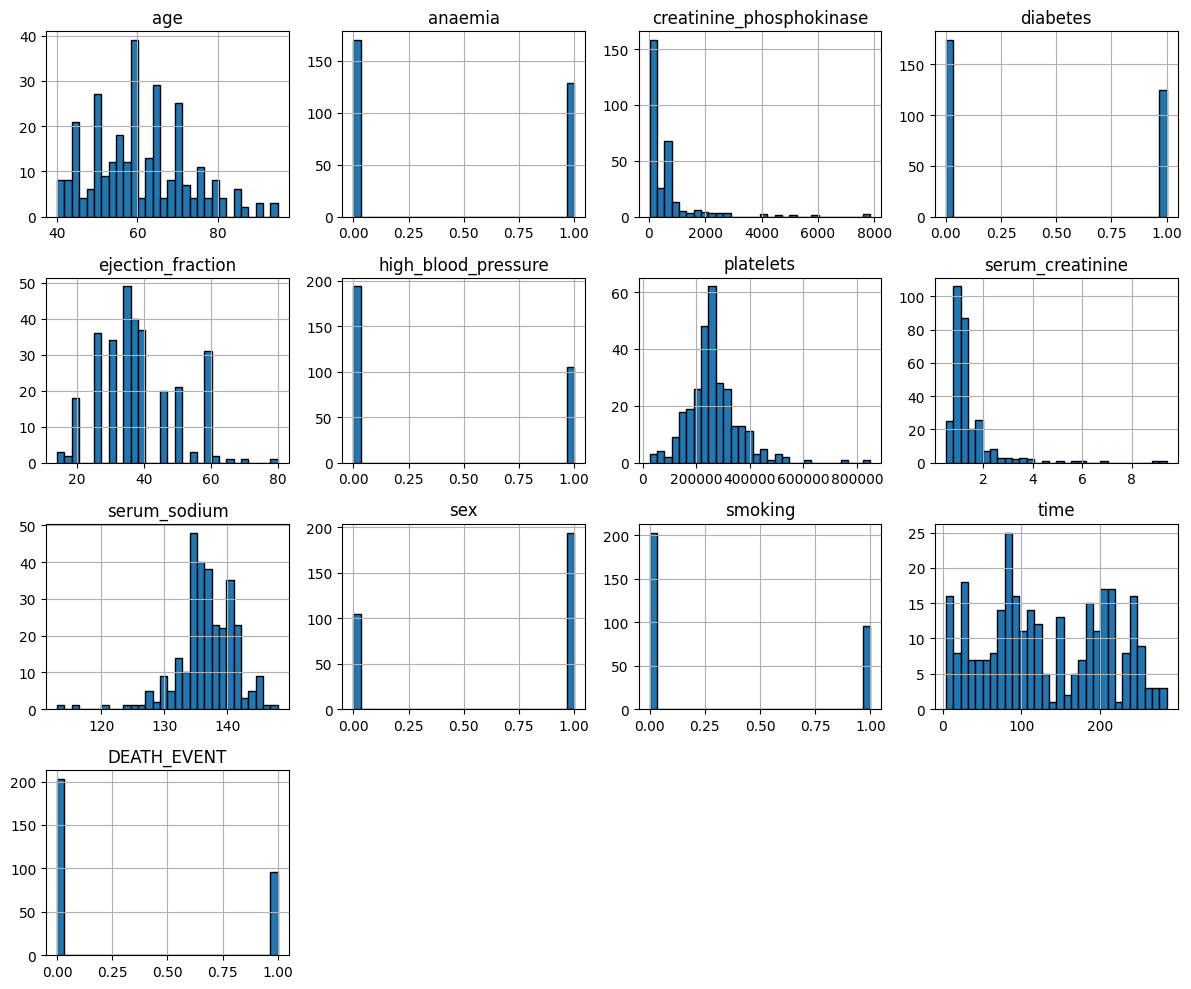

In [ ]:
# Tracer des histogrammes pour toutes les colonnes numériques
data.hist(bins=30, figsize=(12, 10), edgecolor='black')

# Afficher les graphiques
plt.tight_layout()
plt.show()

Matrice de corrélation

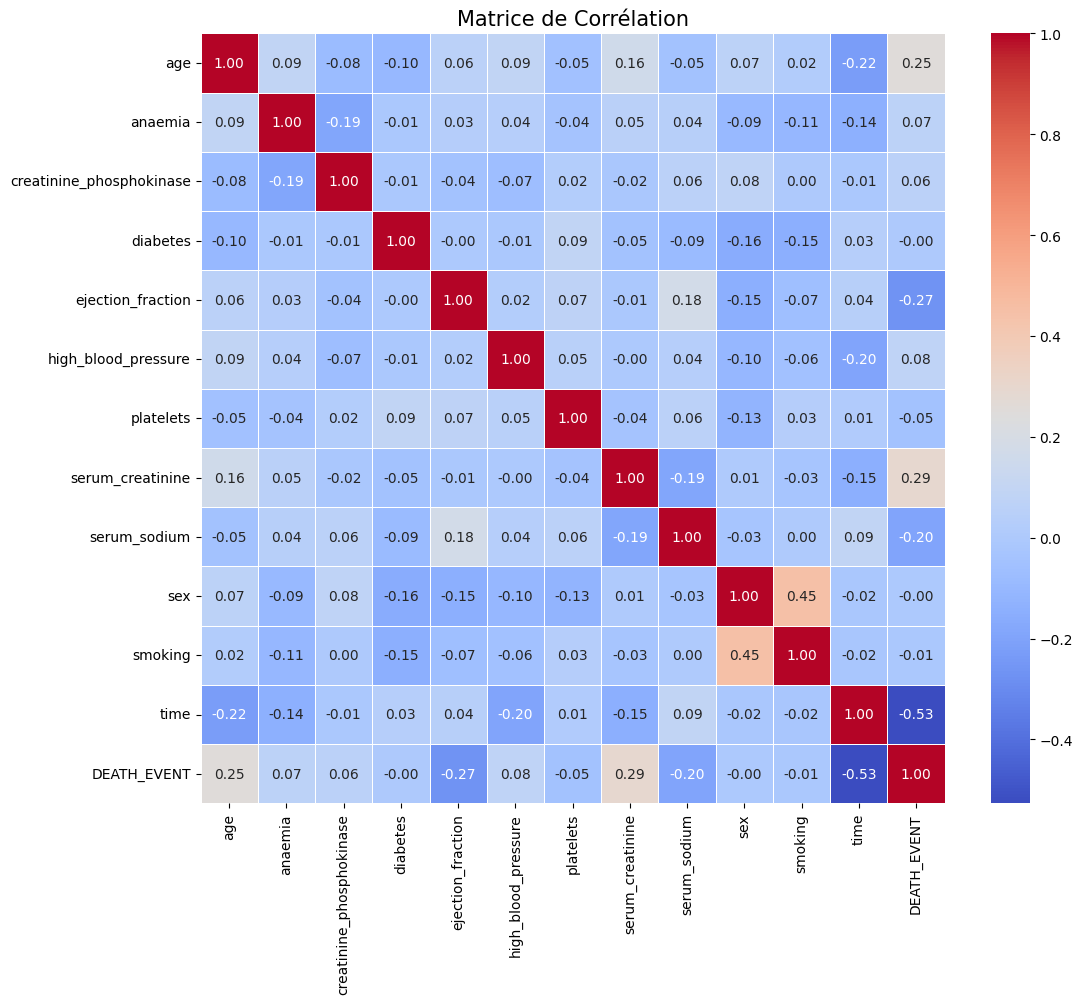

In [ ]:
# Calcul de la matrice de corrélation
corr = data.corr()

# Tracer la heatmap avec les annotations des valeurs de corrélation
plt.figure(figsize=(12, 10))  # Ajuster la taille de la figure selon le nombre de colonnes
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", cbar=True, linewidths=0.5)

# Ajouter un titre
plt.title('Matrice de Corrélation', fontsize=15)

# Afficher la heatmap
plt.show()

Boxplots par Feature

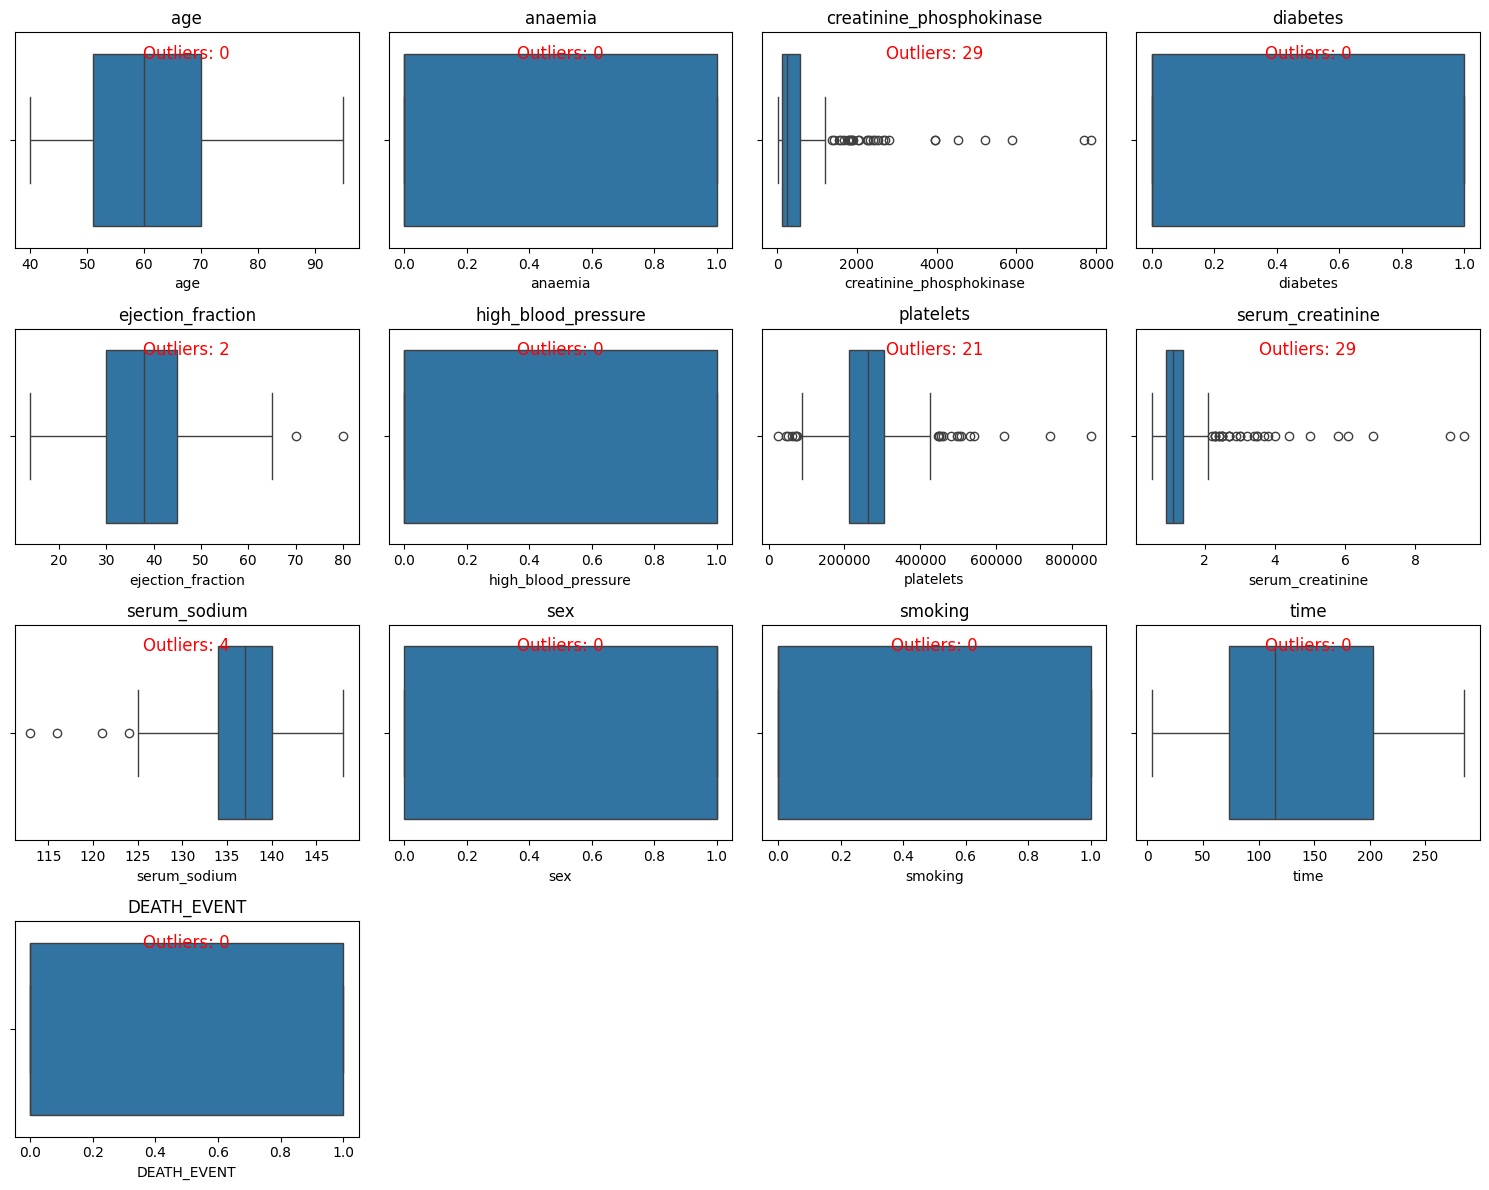

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Définir la taille de la figure
plt.figure(figsize=(15, 12))

# Calculer et afficher le nombre de valeurs aberrantes pour chaque variable
for i, col in enumerate(data.select_dtypes(include=['number']).columns):
    plt.subplot(4, 4, i + 1)  # Ajuste selon le nombre de colonnes
    sns.boxplot(x=data[col])
    plt.title(col)

    # Calcul des valeurs aberrantes
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Compter les valeurs aberrantes
    outliers = data[(data[col] < lower_bound) | (data[col] > upper_bound)]
    num_outliers = outliers.shape[0]

    # Afficher le nombre de valeurs aberrantes sur le graphique
    plt.text(0.5, 0.9, f'Outliers: {num_outliers}', ha='center', va='center', transform=plt.gca().transAxes, fontsize=12, color='red')

plt.tight_layout()
plt.show()


**Prétraitement de données**

Prétraitement les valeurs aberrantes par la méthode de Médiane

In [ ]:
import pandas as pd

# Créer une copie de la base de données d'origine pour éviter de modifier l'original
datanew = data.copy()

# Parcourir chaque colonne numérique
for col in datanew.select_dtypes(include=['number']).columns:
    # Calcul des valeurs aberrantes
    Q1 = datanew[col].quantile(0.25)
    Q3 = datanew[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Calcul de la médiane de la colonne
    median = datanew[col].median()

    # Remplacer les valeurs aberrantes par la médiane
    datanew[col] = datanew[col].apply(lambda x: median if x < lower_bound or x > upper_bound else x)

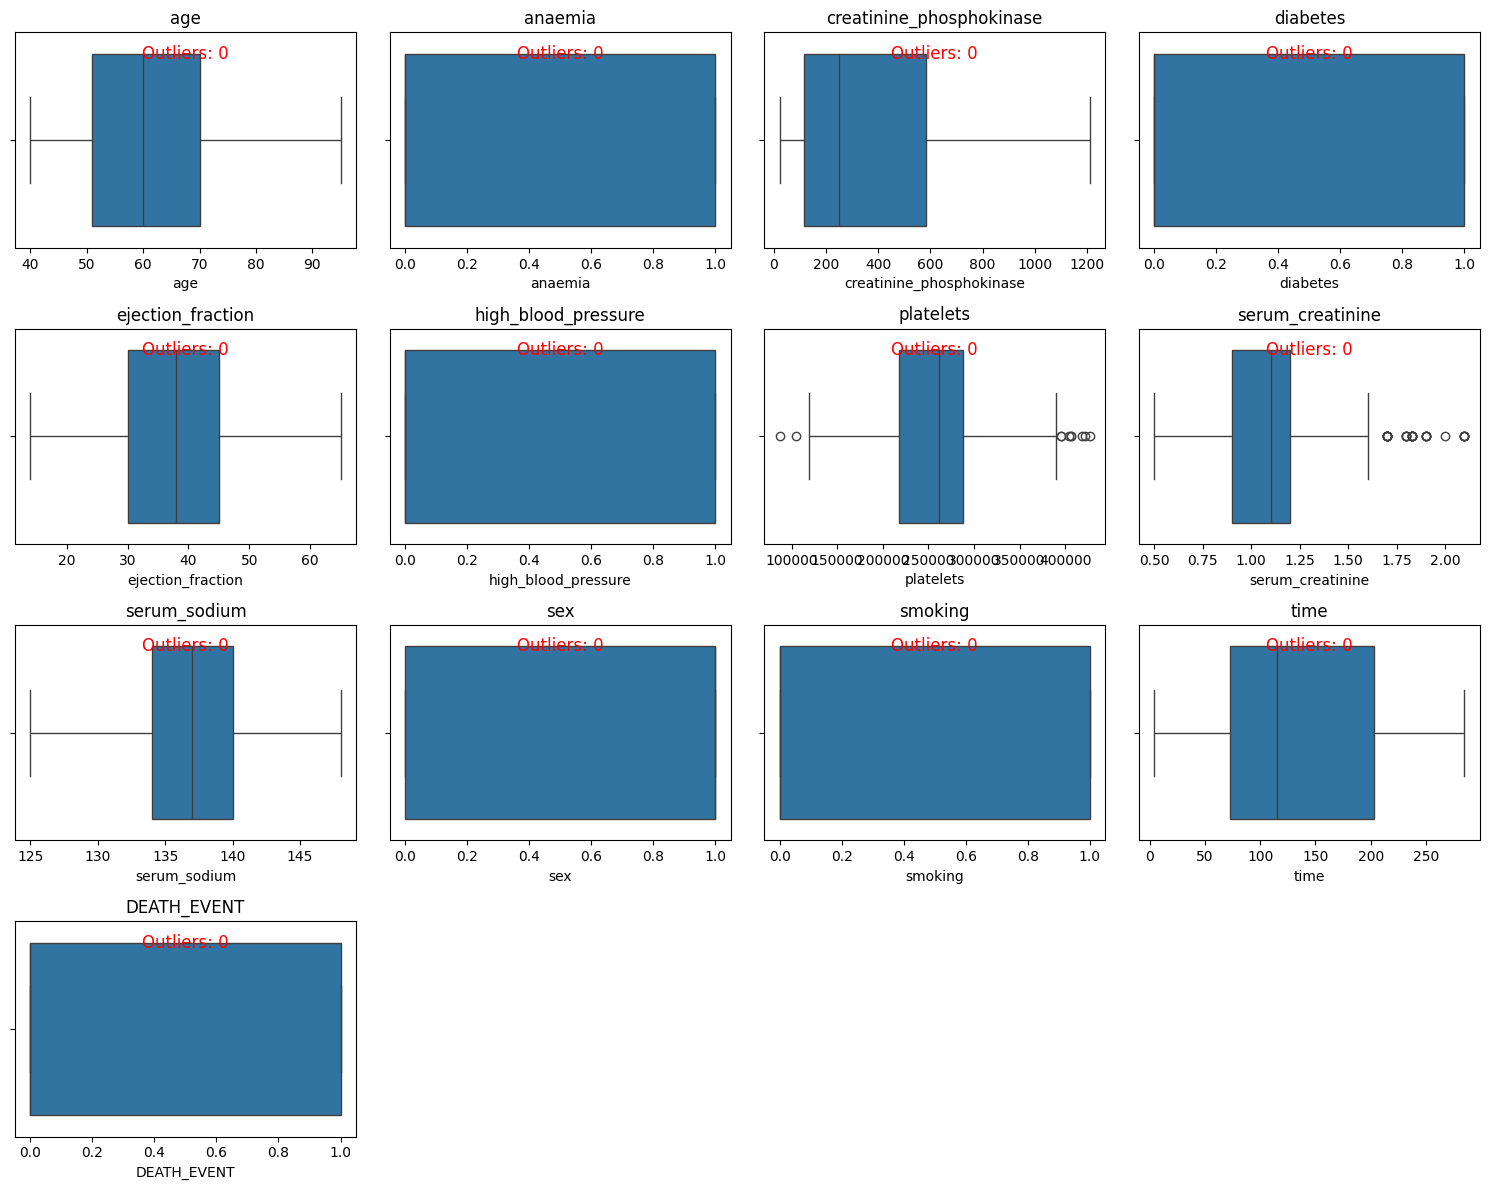

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Définir la taille de la figure
plt.figure(figsize=(15, 12))

# Calculer et afficher le nombre de valeurs aberrantes pour chaque variable
for i, col in enumerate(datanew.select_dtypes(include=['number']).columns):
    plt.subplot(4, 4, i + 1)  # Ajuste selon le nombre de colonnes
    sns.boxplot(x=datanew[col])
    plt.title(col)

    # Calcul des valeurs aberrantes
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Compter les valeurs aberrantes
    outliers = datanew[(datanew[col] < lower_bound) | (datanew[col] > upper_bound)]
    num_outliers = outliers.shape[0]

    # Afficher le nombre de valeurs aberrantes sur le graphique
    plt.text(0.5, 0.9, f'Outliers: {num_outliers}', ha='center', va='center', transform=plt.gca().transAxes, fontsize=12, color='red')

plt.tight_layout()
plt.show()

X Équilibrage du jeu de données (Data balancing)

X Resampling par la méthode oversampling avec SMOTE pour atteindre 203 pour chaque classe dans le target

**Séparation des features et de la target pour la suite du traitement**

In [ ]:
X = datanew.drop('DEATH_EVENT', axis=1)
y_final = datanew['DEATH_EVENT']

**Normalisation des données**

In [ ]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Initialiser le scaler
scaler = StandardScaler()

# Appliquer le scaling sur les données équilibrées
data_scaled = scaler.fit_transform(X)

# Convertir le tableau NumPy en DataFrame
X_final = pd.DataFrame(data_scaled, columns=X.columns)

# Afficher les premières lignes du DataFrame mis à l'échelle
X_final.head(80)
X_final.shape

(406, 12)

**Séparation du dataset
en un jeu d'entraînement et un jeu de test**

In [ ]:
# Séparation des données (validation simple). On peut demander la validation croisée)
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test= train_test_split(X_final, y_final, test_size=0.2, random_state=0)
Y_train.shape

(324,)

**Implèmentation des modèles de ML et DL**

XGBoost Classifier **el houssine kamili**

XGBoost Classifier:
Accuracy: 0.9146
Precision: 0.9167
Recall: 0.9362
F1-Score: 0.9263
ROC-AUC: 0.9416


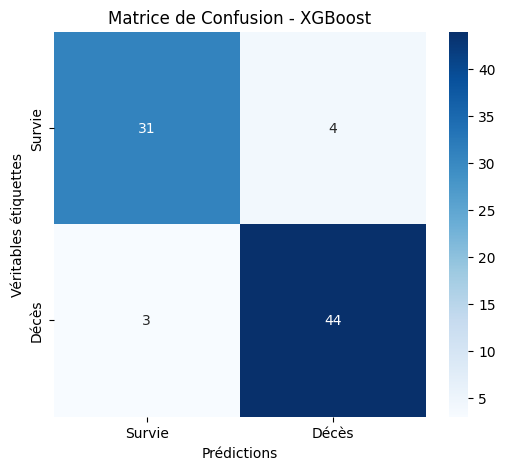

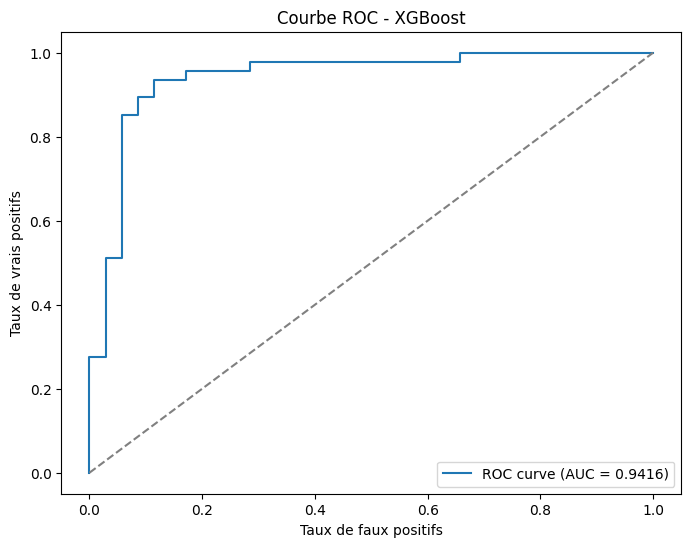

In [ ]:
# XGBoost Classifier
import xgboost as xgb
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

# Entraînement du modèle
xgb_model = xgb.XGBClassifier(random_state=42)
xgb_model.fit(X_train, Y_train)

# Prédictions
Y_pred_xgb = xgb_model.predict(X_test)
Y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

# Évaluation des métriques
accuracy_xgb = accuracy_score(Y_test, Y_pred_xgb)
precision_xgb = precision_score(Y_test, Y_pred_xgb)
recall_xgb = recall_score(Y_test, Y_pred_xgb)
f1_xgb = f1_score(Y_test, Y_pred_xgb)
roc_auc_xgb = roc_auc_score(Y_test, Y_prob_xgb)

# Affichage des résultats
print("XGBoost Classifier:")
print(f"Accuracy: {accuracy_xgb:.4f}")
print(f"Precision: {precision_xgb:.4f}")
print(f"Recall: {recall_xgb:.4f}")
print(f"F1-Score: {f1_xgb:.4f}")
print(f"ROC-AUC: {roc_auc_xgb:.4f}")

# Matrice de confusion
cm_xgb = confusion_matrix(Y_test, Y_pred_xgb)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_xgb, annot=True, fmt="d", cmap="Blues", xticklabels=["Survie", "Décès"], yticklabels=["Survie", "Décès"])
plt.title("Matrice de Confusion - XGBoost")
plt.xlabel("Prédictions")
plt.ylabel("Véritables étiquettes")
plt.show()

# Courbe ROC
fpr_xgb, tpr_xgb, _ = roc_curve(Y_test, Y_prob_xgb)
plt.figure(figsize=(8, 6))
plt.plot(fpr_xgb, tpr_xgb, label=f"ROC curve (AUC = {roc_auc_xgb:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("Taux de faux positifs")
plt.ylabel("Taux de vrais positifs")
plt.title("Courbe ROC - XGBoost")
plt.legend(loc="lower right")
plt.show()

Logistic Regression (selma)

Logistic Regression:
Accuracy: 0.8537
Precision: 0.8431
Recall: 0.9149
F1-Score: 0.8776
ROC-AUC: 0.8888


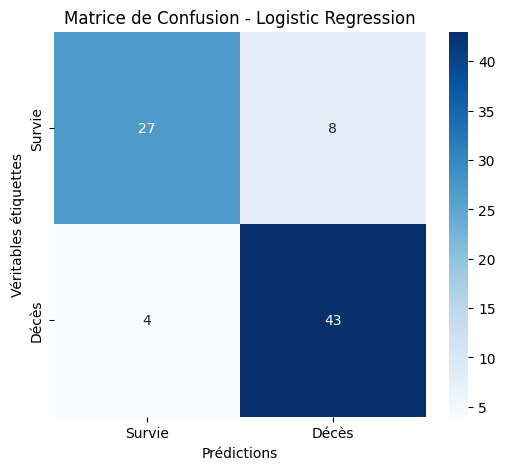

<function matplotlib.pyplot.ylabel(ylabel: 'str', fontdict: 'dict[str, Any] | None' = None, labelpad: 'float | None' = None, *, loc: "Literal['bottom', 'center', 'top'] | None" = None, **kwargs) -> 'Text'>

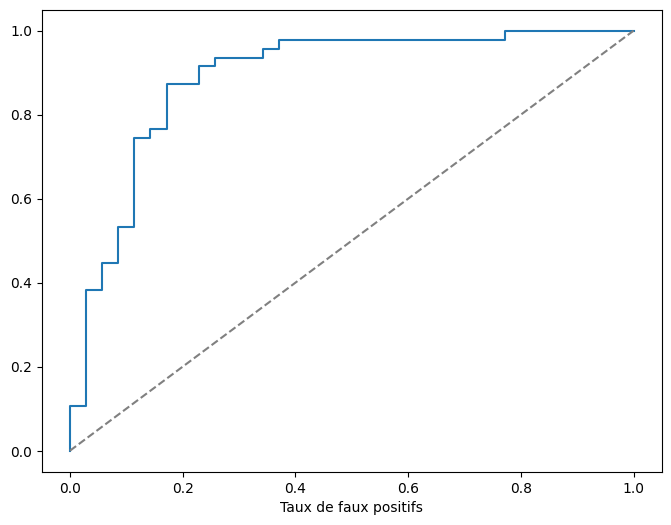

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

# Entraînement du modèle
log_reg_model = LogisticRegression(random_state=42, max_iter=1000)
log_reg_model.fit(X_train, Y_train)

# Prédictions
Y_pred_log_reg = log_reg_model.predict(X_test)
Y_prob_log_reg = log_reg_model.predict_proba(X_test)[:, 1]

# Évaluation des métriques
accuracy_log_reg = accuracy_score(Y_test, Y_pred_log_reg)
precision_log_reg = precision_score(Y_test, Y_pred_log_reg)
recall_log_reg = recall_score(Y_test, Y_pred_log_reg)
f1_log_reg = f1_score(Y_test, Y_pred_log_reg)
roc_auc_log_reg = roc_auc_score(Y_test, Y_prob_log_reg)

# Affichage des résultats
print("Logistic Regression:")
print(f"Accuracy: {accuracy_log_reg:.4f}")
print(f"Precision: {precision_log_reg:.4f}")
print(f"Recall: {recall_log_reg:.4f}")
print(f"F1-Score: {f1_log_reg:.4f}")
print(f"ROC-AUC: {roc_auc_log_reg:.4f}")

# Matrice de confusion
cm_log_reg = confusion_matrix(Y_test, Y_pred_log_reg)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_log_reg, annot=True, fmt="d", cmap="Blues", xticklabels=["Survie", "Décès"], yticklabels=["Survie", "Décès"])
plt.title("Matrice de Confusion - Logistic Regression")
plt.xlabel("Prédictions")
plt.ylabel("Véritables étiquettes")
plt.show()

# Courbe ROC
fpr_log_reg, tpr_log_reg, _ = roc_curve(Y_test, Y_prob_log_reg)
plt.figure(figsize=(8, 6))
plt.plot(fpr_log_reg, tpr_log_reg, label=f"ROC curve (AUC = {roc_auc_log_reg:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("Taux de faux positifs")
plt.ylabel

LightGBM Classifier **chahida**

c:\Users\princ\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


    age  anaemia  creatinine_phosphokinase  diabetes  ejection_fraction  \
0  75.0        0                       582         0                 20   
1  55.0        0                      7861         0                 38   
2  65.0        0                       146         0                 20   
3  50.0        1                       111         0                 20   
4  65.0        1                       160         1                 20   

   high_blood_pressure  platelets  serum_creatinine  serum_sodium  sex  \
0                    1  265000.00               1.9           130    1   
1                    0  263358.03               1.1           136    1   
2                    0  162000.00               1.3           129    1   
3                    0  210000.00               1.9           137    1   
4                    0  327000.00               2.7           116    0   

   smoking  time  DEATH_EVENT  
0        0     4            1  
1        0     6            1  
2       

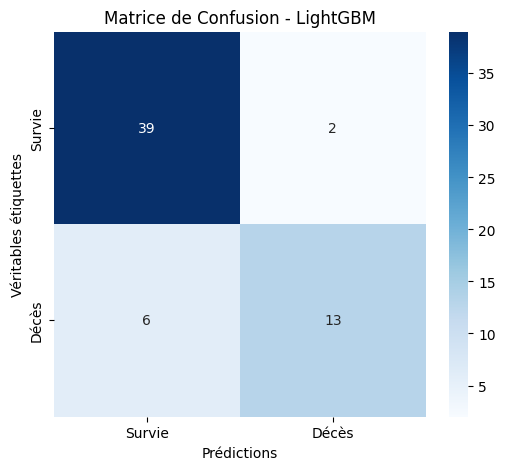

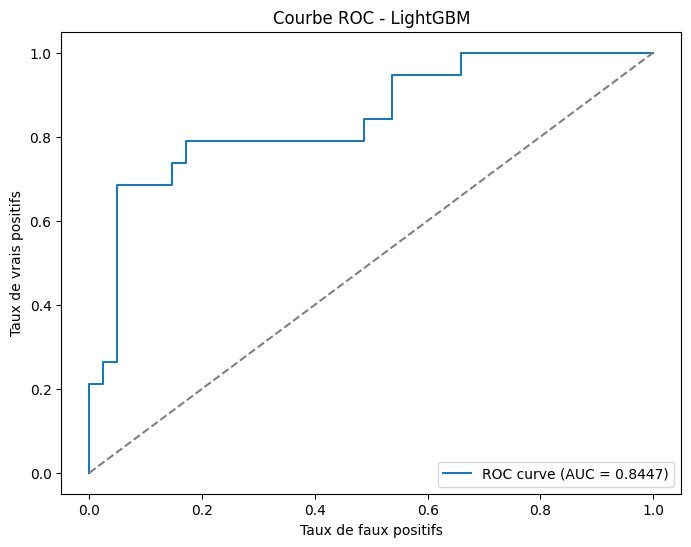

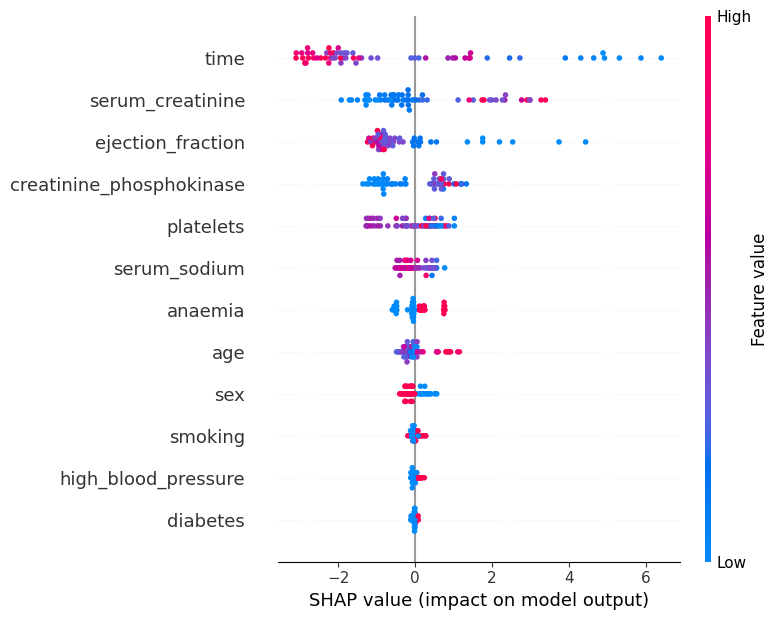

'# LightGBM Classifier\nimport lightgbm as lgb\nfrom sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve\nimport matplotlib.pyplot as plt\nimport seaborn as sns\n\n# Entraînement du modèle\nlgb_model = lgb.LGBMClassifier(random_state=42)\nlgb_model.fit(X_train, Y_train)\n\n# Prédictions\nY_pred_lgb = lgb_model.predict(X_test)\nY_prob_lgb = lgb_model.predict_proba(X_test)[:, 1]\n\n# Évaluation des métriques\naccuracy_lgb = accuracy_score(Y_test, Y_pred_lgb)\nprecision_lgb = precision_score(Y_test, Y_pred_lgb)\nrecall_lgb = recall_score(Y_test, Y_pred_lgb)\nf1_lgb = f1_score(Y_test, Y_pred_lgb)\nroc_auc_lgb = roc_auc_score(Y_test, Y_prob_lgb)\n\n# Affichage des résultats\nprint("LightGBM Classifier:")\nprint(f"Accuracy: {accuracy_lgb:.4f}")\nprint(f"Precision: {precision_lgb:.4f}")\nprint(f"Recall: {recall_lgb:.4f}")\nprint(f"F1-Score: {f1_lgb:.4f}")\nprint(f"ROC-AUC: {roc_auc_lgb:.4f}")\n\n# Matrice de confusion\ncm_

In [1]:
import lightgbm as lgb
import shap
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (roc_auc_score, accuracy_score, precision_score, 
                             recall_score, f1_score, confusion_matrix, roc_curve)
from sklearn.model_selection import StratifiedKFold
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split
import pandas as pd

# Charger un fichier CSV (remplace "mon_fichier.csv" par le bon nom de fichier)
df = pd.read_csv("C:\\Users\\princ\\Documents\\GitHub\\heart-failure-prediction\\notebooks\\heart_failure_clinical_records_dataset.csv")

# Vérifier le contenu
print(df.head())


# Supposons que df soit ton DataFrame et 'target' la colonne cible
X = df.drop(columns=['DEATH_EVENT'])
Y = df['DEATH_EVENT']

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)


# Calcul du poids des classes pour gérer le déséquilibre
target_values = np.unique(Y_train)
class_weights = compute_class_weight('balanced', classes=target_values, y=Y_train)
class_weight_dict = {target_values[i]: class_weights[i] for i in range(len(target_values))}

# Entraînement du modèle avec ajustement du poids des classes
lgb_model = lgb.LGBMClassifier(random_state=42, scale_pos_weight=class_weight_dict[1])
lgb_model.fit(X_train, Y_train)

# Prédictions
Y_prob_lgb = lgb_model.predict_proba(X_test)[:, 1]

# Optimisation du seuil de décision
fpr, tpr, thresholds = roc_curve(Y_test, Y_prob_lgb)
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]
Y_pred_lgb = (Y_prob_lgb >= optimal_threshold).astype(int)

# Évaluation des métriques
accuracy_lgb = accuracy_score(Y_test, Y_pred_lgb)
precision_lgb = precision_score(Y_test, Y_pred_lgb)
recall_lgb = recall_score(Y_test, Y_pred_lgb)
f1_lgb = f1_score(Y_test, Y_pred_lgb)
roc_auc_lgb = roc_auc_score(Y_test, Y_prob_lgb)

print("LightGBM Classifier:")
print(f"Accuracy: {accuracy_lgb:.4f}")
print(f"Precision: {precision_lgb:.4f}")
print(f"Recall: {recall_lgb:.4f}")  # Très important en contexte médical
print(f"F1-Score: {f1_lgb:.4f}")
print(f"ROC-AUC: {roc_auc_lgb:.4f}")
print(f"Seuil optimal: {optimal_threshold:.4f}")

# Matrice de confusion
cm_lgb = confusion_matrix(Y_test, Y_pred_lgb)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_lgb, annot=True, fmt="d", cmap="Blues", xticklabels=["Survie", "Décès"], yticklabels=["Survie", "Décès"])
plt.title("Matrice de Confusion - LightGBM")
plt.xlabel("Prédictions")
plt.ylabel("Véritables étiquettes")
plt.show()

# Courbe ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc_lgb:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("Taux de faux positifs")
plt.ylabel("Taux de vrais positifs")
plt.title("Courbe ROC - LightGBM")
plt.legend(loc="lower right")
plt.show()

# Explicabilité avec SHAP
explainer = shap.Explainer(lgb_model, X_train)
shap_values = explainer(X_test)
shap.summary_plot(shap_values, X_test)  # Affiche les features les plus influentes
'''# LightGBM Classifier
import lightgbm as lgb
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

# Entraînement du modèle
lgb_model = lgb.LGBMClassifier(random_state=42)
lgb_model.fit(X_train, Y_train)

# Prédictions
Y_pred_lgb = lgb_model.predict(X_test)
Y_prob_lgb = lgb_model.predict_proba(X_test)[:, 1]

# Évaluation des métriques
accuracy_lgb = accuracy_score(Y_test, Y_pred_lgb)
precision_lgb = precision_score(Y_test, Y_pred_lgb)
recall_lgb = recall_score(Y_test, Y_pred_lgb)
f1_lgb = f1_score(Y_test, Y_pred_lgb)
roc_auc_lgb = roc_auc_score(Y_test, Y_prob_lgb)

# Affichage des résultats
print("LightGBM Classifier:")
print(f"Accuracy: {accuracy_lgb:.4f}")
print(f"Precision: {precision_lgb:.4f}")
print(f"Recall: {recall_lgb:.4f}")
print(f"F1-Score: {f1_lgb:.4f}")
print(f"ROC-AUC: {roc_auc_lgb:.4f}")

# Matrice de confusion
cm_lgb = confusion_matrix(Y_test, Y_pred_lgb)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_lgb, annot=True, fmt="d", cmap="Blues", xticklabels=["Survie", "Décès"], yticklabels=["Survie", "Décès"])
plt.title("Matrice de Confusion - LightGBM")
plt.xlabel("Prédictions")
plt.ylabel("Véritables étiquettes")
plt.show()

# Courbe ROC
fpr_lgb, tpr_lgb, _ = roc_curve(Y_test, Y_prob_lgb)
plt.figure(figsize=(8, 6))
plt.plot(fpr_lgb, tpr_lgb, label=f"ROC curve (AUC = {roc_auc_lgb:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("Taux de faux positifs")
plt.ylabel("Taux de vrais positifs")
plt.title("Courbe ROC - LightGBM")
plt.legend(loc="lower right")
plt.show()'''


Random Forest Classifier **el houssine kamili**

Random Forest Classifier:
Accuracy: 0.8902
Precision: 0.8958
Recall: 0.9149
F1-Score: 0.9053
ROC-AUC: 0.9772


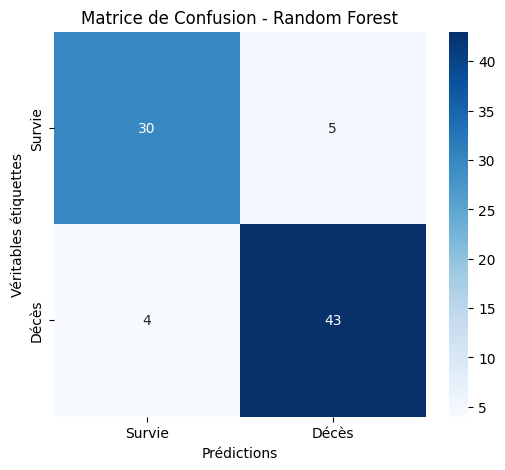

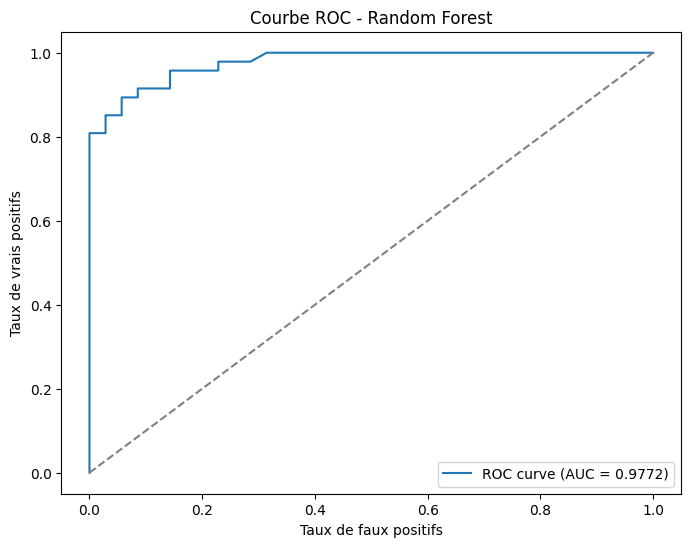

In [ ]:
# Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

# Entraînement du modèle
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, Y_train)

# Prédictions
Y_pred_rf = rf_model.predict(X_test)
Y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

# Évaluation des métriques
accuracy_rf = accuracy_score(Y_test, Y_pred_rf)
precision_rf = precision_score(Y_test, Y_pred_rf)
recall_rf = recall_score(Y_test, Y_pred_rf)
f1_rf = f1_score(Y_test, Y_pred_rf)
roc_auc_rf = roc_auc_score(Y_test, Y_prob_rf)

# Affichage des résultats
print("Random Forest Classifier:")
print(f"Accuracy: {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall: {recall_rf:.4f}")
print(f"F1-Score: {f1_rf:.4f}")
print(f"ROC-AUC: {roc_auc_rf:.4f}")

# Matrice de confusion
cm_rf = confusion_matrix(Y_test, Y_pred_rf)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Blues", xticklabels=["Survie", "Décès"], yticklabels=["Survie", "Décès"])
plt.title("Matrice de Confusion - Random Forest")
plt.xlabel("Prédictions")
plt.ylabel("Véritables étiquettes")
plt.show()

# Courbe ROC
fpr_rf, tpr_rf, _ = roc_curve(Y_test, Y_prob_rf)
plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, label=f"ROC curve (AUC = {roc_auc_rf:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("Taux de faux positifs")
plt.ylabel("Taux de vrais positifs")
plt.title("Courbe ROC - Random Forest")
plt.legend(loc="lower right")
plt.show()
